# External-product consistency of inferred ice thickness and snow depth

This notebook compares the out-of-fold latent estimates with the March 2020
IS2SITMOGR4 version 003 monthly product at 53 locations within 12.5 km.

## Scope: this is not independent truth

IS2SITMOGR4 ice thickness is itself calculated from ICESat-2 ATL10 freeboard
and redistributed NESOSIM v1.1 snow loading. Its snow-depth field is the
redistributed NESOSIM estimate. Our retrieval uses collocated ICESat-2
freeboard, so the reference shares an input sensor and modelling assumptions.

The results below must therefore be described as **external-product
consistency**, not independent validation or retrieval accuracy.


## Coordinate correction

The server preprocessing treated the source polar stereographic coordinates as
having `lon_0=0` on WGS84. The NetCDF metadata specify EPSG:3411, whose central
meridian is −45° and whose ellipsoid is Hughes 1980. The stored transformed
coordinates differ from the metadata-correct transformation by approximately:

- minimum: 154 km;
- median: 1,128 km;
- maximum: 3,312 km.

Consequently, RMSE calculations using the old transformed coordinates are not
reliable. This notebook reprojects the original `og_x, og_y` coordinates from
EPSG:3411 to EASE2 North and uses a maximum match distance of 12.5 km, half of
the 25 km reference grid spacing.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt(
    '../results/external_reference_model_comparison.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
metrics = np.genfromtxt(
    '../results/external_reference_consistency_metrics.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
summary = json.load(open('../results/external_reference_consistency_summary.json'))

distance_km = (data['x_m'] - data['x_m'].min()) / 1000.0
print('Matched locations:', len(data))
print('Match-distance range (km):',
      (float(data['reference_distance_m'].min()/1000),
       float(data['reference_distance_m'].max()/1000)))
print('Reference status:', summary['reference']['independence_status'])


Matched locations: 53
Match-distance range (km): (2.809830606919689, 12.01735395350465)
Reference status: external comparison product, not independent truth


## Consistency metrics


In [2]:
for method in ['Point + linear', 'Nested linear GP', 'Positive GP', 'Hard-positive DRF']:
    print(method)
    rows = metrics[metrics['method'] == method]
    for latent in ['Hi', 'Hs']:
        row = rows[rows['latent'] == latent][0]
        print(
            f"  {latent}: RMSE={row['RMSE_m']:.3f} m, "
            f"MAE={row['MAE_m']:.3f} m, bias={row['bias_m']:.3f} m, "
            f"r={row['correlation']:.3f}"
        )


Point + linear
  Hi: RMSE=0.928 m, MAE=0.569 m, bias=-0.061 m, r=0.318
  Hs: RMSE=0.086 m, MAE=0.075 m, bias=-0.057 m, r=0.422
Nested linear GP
  Hi: RMSE=0.887 m, MAE=0.497 m, bias=-0.228 m, r=0.463
  Hs: RMSE=0.077 m, MAE=0.063 m, bias=-0.034 m, r=0.410
Positive GP
  Hi: RMSE=0.952 m, MAE=0.596 m, bias=-0.149 m, r=0.271
  Hs: RMSE=0.081 m, MAE=0.067 m, bias=-0.051 m, r=0.223
Hard-positive DRF
  Hi: RMSE=0.895 m, MAE=0.628 m, bias=0.124 m, r=0.403
  Hs: RMSE=0.071 m, MAE=0.062 m, bias=-0.030 m, r=0.808


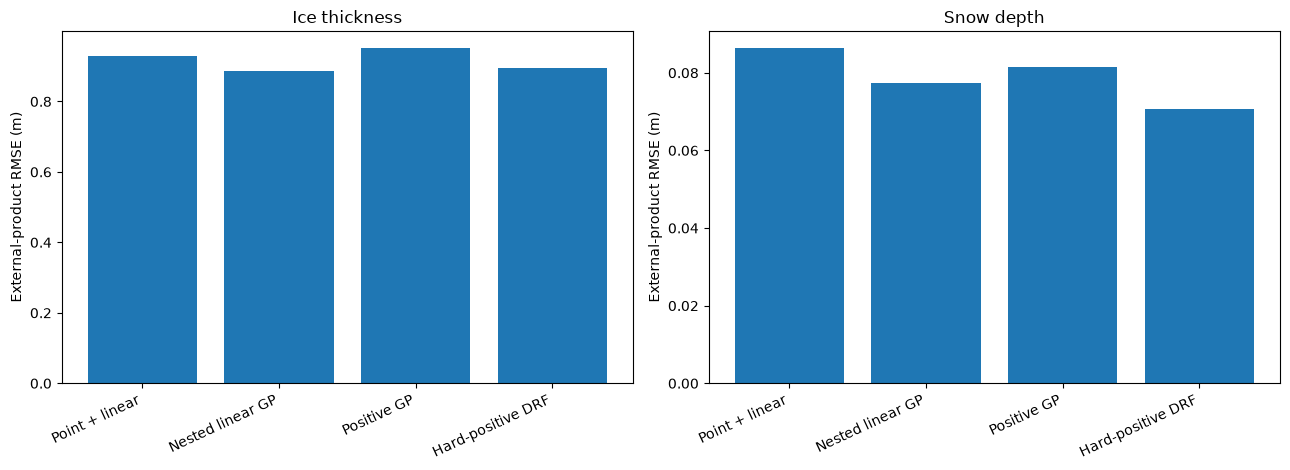

In [3]:
methods = ['Point + linear', 'Nested linear GP', 'Positive GP', 'Hard-positive DRF']
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, latent in zip(axs, ['Hi', 'Hs']):
    values = [float(metrics['RMSE_m'][(metrics['method']==m) & (metrics['latent']==latent)][0]) for m in methods]
    ax.bar(np.arange(len(methods)), values)
    ax.set_xticks(np.arange(len(methods)), methods, rotation=25, ha='right')
    ax.set_ylabel('External-product RMSE (m)')
    ax.set_title('Ice thickness' if latent == 'Hi' else 'Snow depth')
plt.tight_layout()


## Along-transect comparison


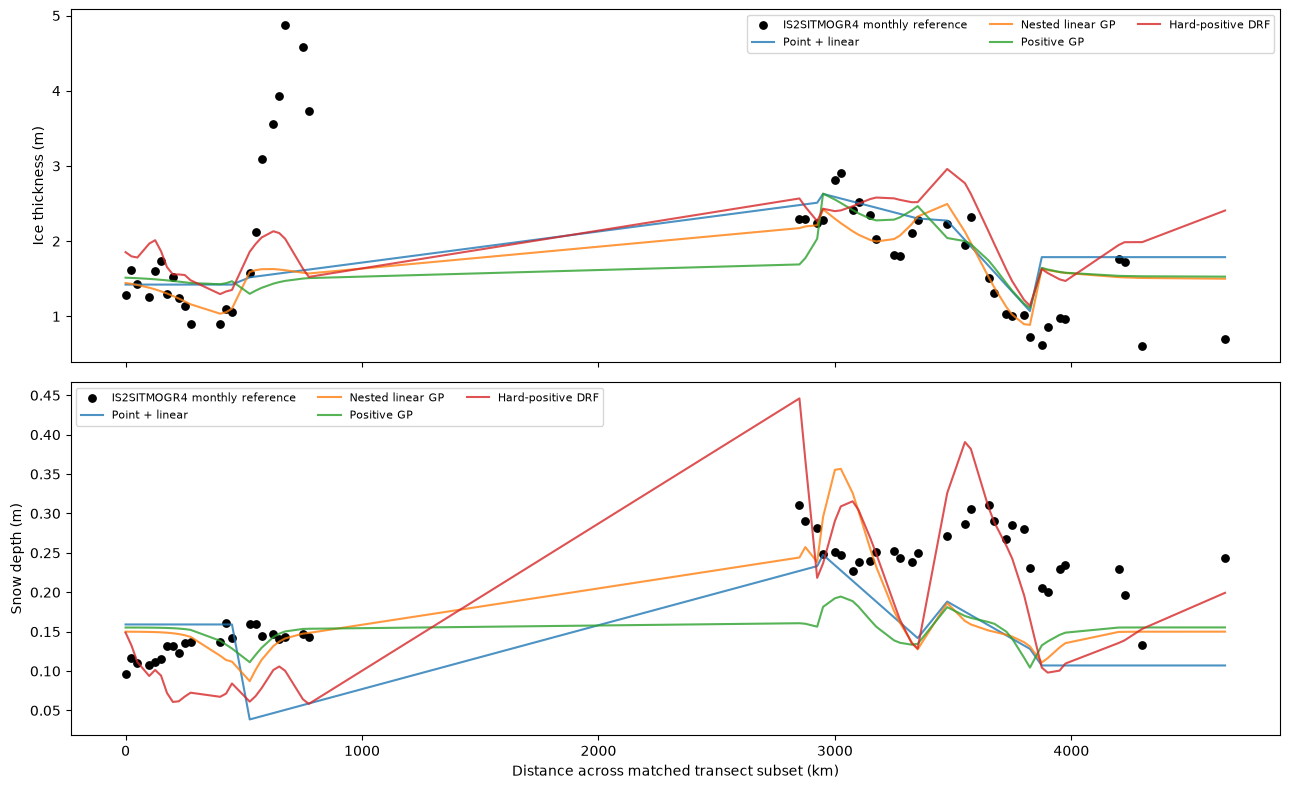

In [4]:
method_columns = {
    'Point + linear': ('point_Hi_m', 'point_Hs_m'),
    'Nested linear GP': ('nested_gp_Hi_m', 'nested_gp_Hs_m'),
    'Positive GP': ('positive_gp_Hi_m', 'positive_gp_Hs_m'),
    'Hard-positive DRF': ('drf_Hi_m', 'drf_Hs_m'),
}
fig, axs = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
references = ['reference_Hi_m', 'reference_Hs_m']
labels = ['Ice thickness (m)', 'Snow depth (m)']
for j, ax in enumerate(axs):
    order = np.argsort(distance_km)
    ax.scatter(distance_km[order], data[references[j]][order], s=28,
               color='black', label='IS2SITMOGR4 monthly reference')
    for method, columns in method_columns.items():
        ax.plot(distance_km[order], data[columns[j]][order], label=method, alpha=.8)
    ax.set_ylabel(labels[j])
    ax.legend(ncol=3, fontsize=8)
axs[-1].set_xlabel('Distance across matched transect subset (km)')
plt.tight_layout()


## Pointwise agreement and spatial-mismatch diagnostic


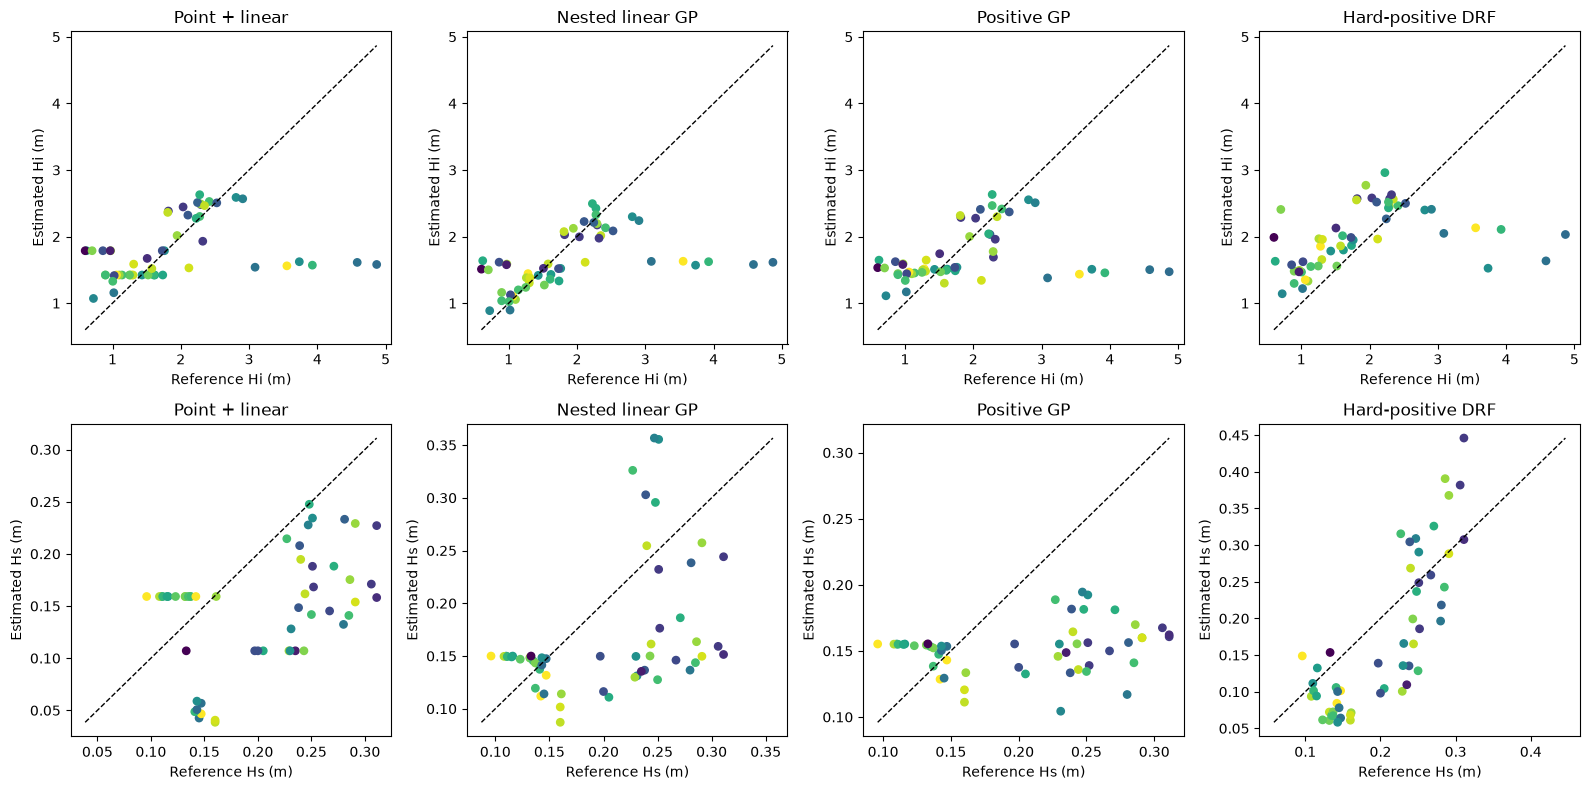

In [5]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for col, (method, columns) in enumerate(method_columns.items()):
    for row, (reference_name, prediction_name, latent) in enumerate([
        ('reference_Hi_m', columns[0], 'Hi'),
        ('reference_Hs_m', columns[1], 'Hs'),
    ]):
        ax = axs[row, col]
        ax.scatter(data[reference_name], data[prediction_name],
                   c=data['reference_distance_m']/1000, cmap='viridis', s=28)
        low = min(data[reference_name].min(), data[prediction_name].min())
        high = max(data[reference_name].max(), data[prediction_name].max())
        ax.plot([low, high], [low, high], 'k--', lw=1)
        ax.set_title(method)
        ax.set_xlabel(f'Reference {latent} (m)')
        ax.set_ylabel(f'Estimated {latent} (m)')
plt.tight_layout()


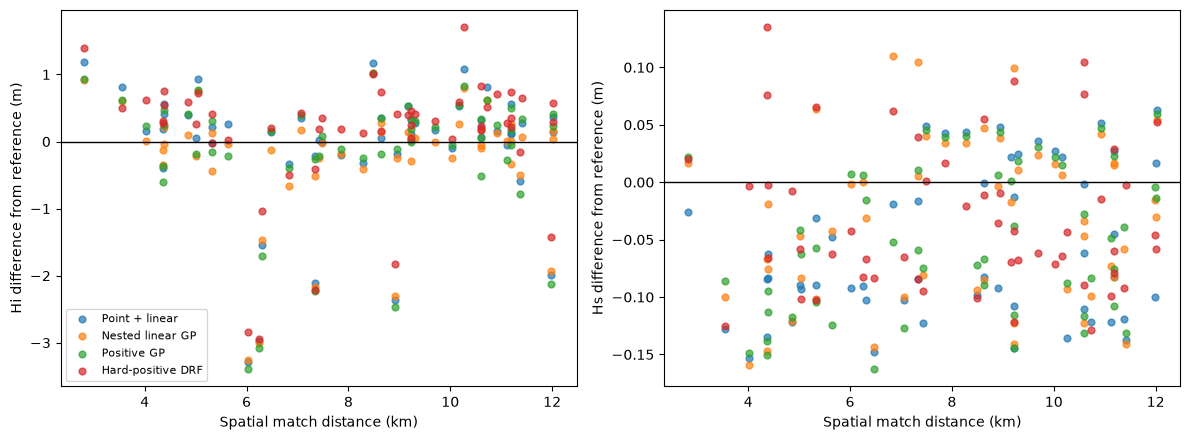

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, reference_name, latent in [
    (axs[0], 'reference_Hi_m', 'Hi'),
    (axs[1], 'reference_Hs_m', 'Hs'),
]:
    for method, columns in method_columns.items():
        prediction_name = columns[0] if latent == 'Hi' else columns[1]
        error = data[prediction_name] - data[reference_name]
        ax.scatter(data['reference_distance_m']/1000, error, s=24, alpha=.7, label=method)
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('Spatial match distance (km)')
    ax.set_ylabel(f'{latent} difference from reference (m)')
axs[0].legend(fontsize=8)
plt.tight_layout()


## Evidence-based interpretation

- For ice thickness, the nested linear GP has the smallest reference RMSE
  (0.887 m) and highest correlation (0.463), but the differences between models
  are modest relative to the approximately 0.57 m median reference uncertainty.
- For snow depth, the hard-positive DRF is most consistent with NESOSIM
  (RMSE 0.071 m, correlation 0.808). This does not prove snow-retrieval
  accuracy because the comparison field is a snow model, not snow observation.
- The positive GP's strong held-out freeboard reconstruction does not translate
  into the strongest external-product latent agreement. This demonstrates the
  identifiability problem: two freeboards can be reconstructed well while the
  decomposition into $H_i$ and $H_s$ remains uncertain.
- The reference is monthly while the retrieval window spans 15 days, and
  spatial matches are 2.8–12.0 km apart. Both mismatches contribute to the
  reported differences.
- The pre-existing server validation scripts used seriously misprojected
  coordinates and should not be cited without correction.

The defensible dissertation wording is that this experiment assesses
**consistency with IS2SITMOGR4**, exposes latent non-identifiability, and
motivates genuinely independent validation. Suitable future data would include
airborne electromagnetic or Operation IceBridge thickness, ice-mass-balance
buoys, and airborne snow-radar measurements with documented collocation and
uncertainty.
